In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# чтение файла и вывод первых 5-и элементов
houses = pd.read_csv("1.4_houses.csv")
houses.head(5)

,dim_1,dim_2,level,price
0,29,28,luxury,2212.0
1,28,29,luxury,2203.0
2,6,9,basic,254.0
3,5,9,basic,242.0
4,6,6,basic,195.0


<AxesSubplot: xlabel='dim_1', ylabel='price'>

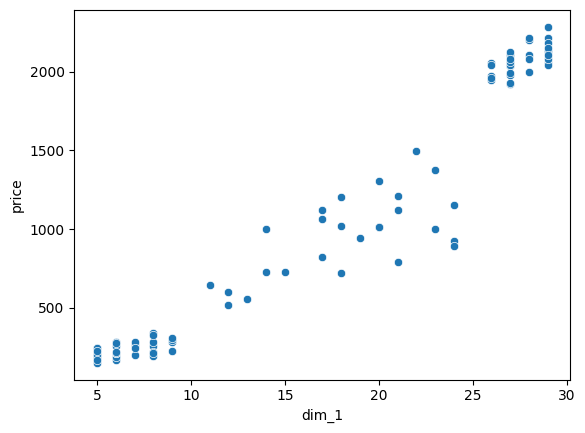

In [4]:
# вывод таблицы значений dim_1
sns.scatterplot(data=houses, x="dim_1", y="price")

In [90]:
# импорт исследуемых данных
from sklearn.linear_model import LinearRegression
X = houses[["dim_1"]]
y = houses["price"]

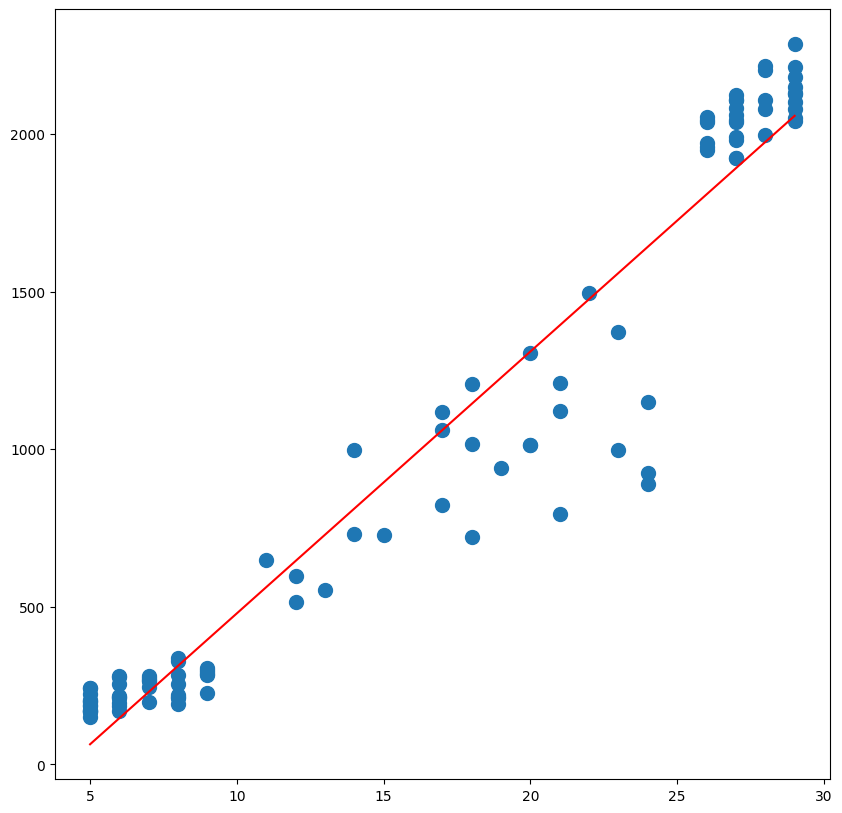

In [47]:
# метод без regplot
reg = LinearRegression().fit(X, y)

[b] = reg.coef_
a = reg.intercept_

def reg_prediction(dim_1):
    return a + b * dim_1

reg_prediction(X.dim_1)

fig = plt.figure(figsize=(10, 10))
ax = plt.axes()

ax.scatter(houses["dim_1"], houses["price"], s=100)
ax.plot([X.dim_1.min(), X.dim_1.max()], [reg_prediction(X.dim_1.min()), reg_prediction(X.dim_1.max())], c="red")

plt.show()

<AxesSubplot: xlabel='dim_1', ylabel='price'>

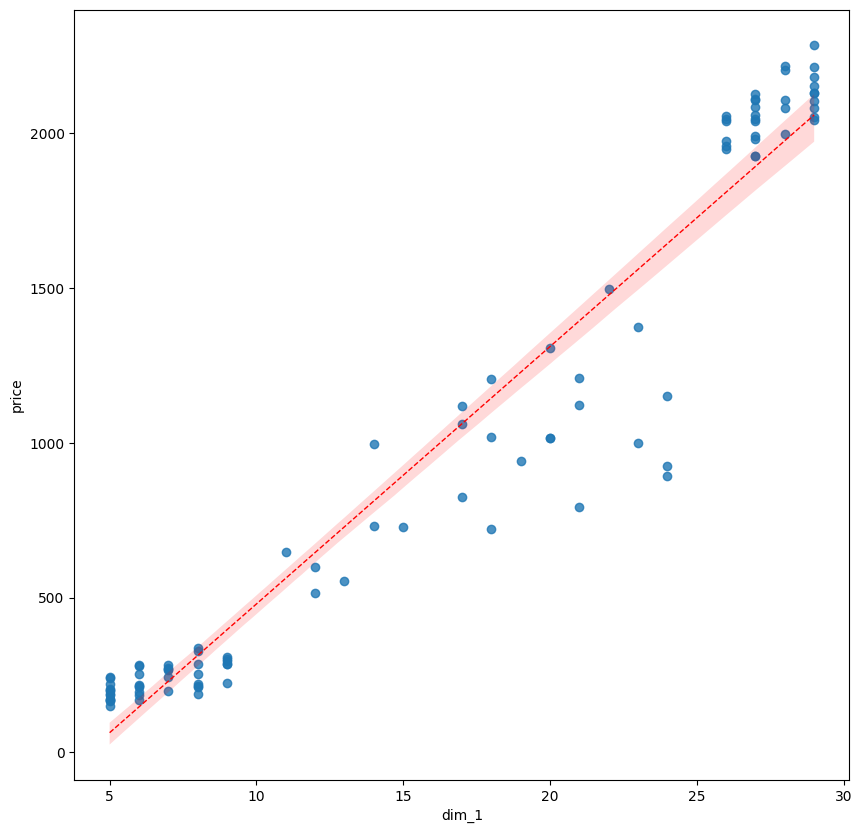

In [91]:
# regplot :)
plt.figure(figsize=(10, 10))
sns.regplot(data=houses, x="dim_1", y="price", 
            line_kws={"color": "r", "linestyle": "--", "linewidth": 1})

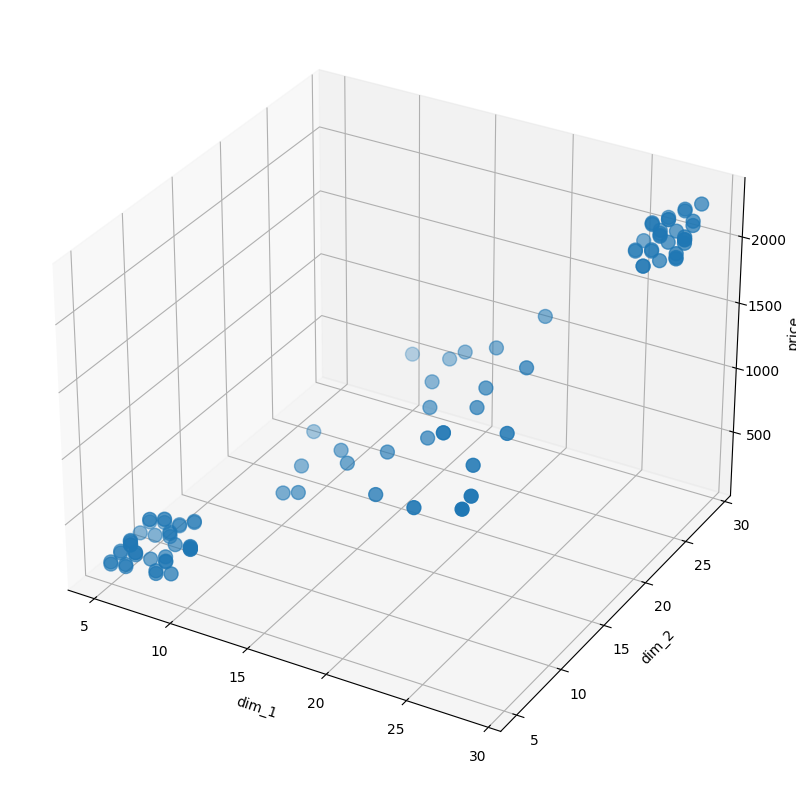

In [5]:
# график зависимости от двух параметров dim_1 dim_2
plt.figure(figsize=(10,10))
ax = plt.axes(projection="3d")

ax.scatter(houses["dim_1"], houses["dim_2"], houses["price"], s=100)

ax.set_xlabel("dim_1")
ax.set_ylabel("dim_2")
ax.set_zlabel("price")

plt.show()

In [6]:
# обучение линейной модели на двух параметрах
from sklearn.linear_model import LinearRegression
X = houses[["dim_1", "dim_2"]]
y = houses["price"]

reg = LinearRegression().fit(X, y)

[b1, b2] = reg.coef_
a = reg.intercept_

def prediction(dim_1, dim_2):
    return a + b1*dim_1 + b2*dim_2

d1, d2 = list(), list()
for x in np.linspace(min(houses["dim_1"]), max(houses["dim_1"]), 100):
    for y in np.linspace(min(houses["dim_2"]), max(houses["dim_2"]), 100):
        d1.append(x)
        d2.append(y)
d1 = np.array(d1).reshape(-1, 1)
d2 = np.array(d2).reshape(-1, 1)

p = reg.predict(np.concatenate([d1, d2], axis=1))


c:\others\python\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


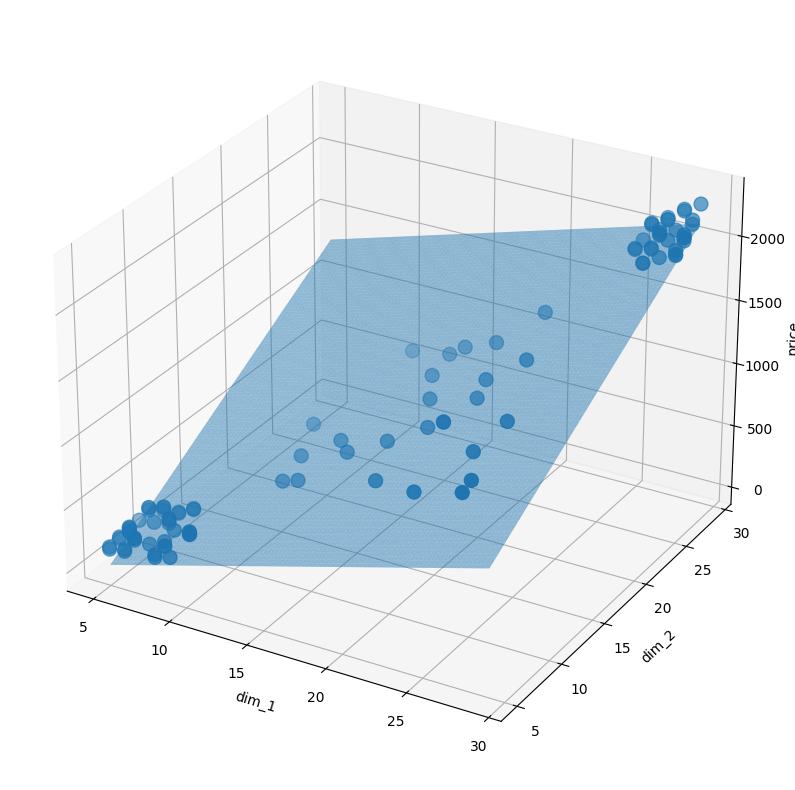

In [8]:
# график плоскости...
plt.figure(figsize=(10, 10))
ax = plt.axes(projection="3d")

ax.scatter(houses["dim_1"], houses["dim_2"], houses["price"], s=100)

ax.plot_trisurf(d1.ravel(), d2.ravel(), p.ravel(), alpha=0.5)

ax.set_xlabel("dim_1")
ax.set_ylabel("dim_2")
ax.set_zlabel("price")

ax.elev = 27
plt.show()

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text

In [6]:
# обучение дерева решений
X = houses[["dim_1", "dim_2"]]
y = houses["level"]

cl = DecisionTreeClassifier().fit(X, y)

print(export_text(cl))

|--- feature_0 <= 10.00
|   |--- class: basic
|--- feature_0 >  10.00
|   |--- feature_1 <= 25.00
|   |   |--- class: medium
|   |--- feature_1 >  25.00
|   |   |--- class: luxury



In [16]:
# сравнение предсказания с данными
cl.predict(X[0:1])[0], y[0]

('luxury', 'luxury')